<a href="https://colab.research.google.com/github/Sushanttyagi2/LIDS-for-Secure-Wireless-Sensor-Networks/blob/main/Notebook/WSN_IDS_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn joblib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

print("✅ Libraries installed and imported successfully!\n")

✅ Libraries installed and imported successfully!



# ===============================
# 1. Realistic WSN Data Generation
# ===============================

In [2]:
def generate_wsn_data(n_samples=1000, attack_ratio=0.25, seed=42):
    np.random.seed(seed)

    # Features for WSN nodes
    data = {
        'node_id': np.arange(1, n_samples + 1),
        'packet_rate': np.random.uniform(10, 120, n_samples),      # packets per unit time
        'drop_rate': np.zeros(n_samples),
        'energy_level': np.random.uniform(0.4, 1.0, n_samples),    # normalized 0-1
        'routing_changes': np.random.poisson(2, n_samples),
        'neighbor_count': np.random.randint(3, 15, n_samples),
        'traffic_anomaly': np.random.uniform(0.5, 2.0, n_samples),
        'label': np.zeros(n_samples, dtype=int)                    # 0 = Normal, 1 = Attack
    }

    n_attacks = int(n_samples * attack_ratio)
    attack_idx = np.random.choice(n_samples, n_attacks, replace=False)
    # Inject different attack behaviors
    for idx in attack_idx:
        attack_type = np.random.choice(['sinkhole', 'selective_forward', 'sybil', 'spoofing'])
        data['label'][idx] = 1

        if attack_type == 'sinkhole':
            data['drop_rate'][idx] = np.random.uniform(0.45, 0.85)
            data['packet_rate'][idx] *= 1.8
        elif attack_type == 'selective_forward':
            data['drop_rate'][idx] = np.random.uniform(0.35, 0.75)
        elif attack_type == 'sybil':
            data['neighbor_count'][idx] = int(data['neighbor_count'][idx] * 2.5)
            data['routing_changes'][idx] += np.random.randint(5, 12)
        elif attack_type == 'spoofing':
            data['energy_level'][idx] = np.random.uniform(0.05, 0.35)
            data['routing_changes'][idx] += np.random.randint(6, 15)
    # Normal nodes have low drop rate
    normal_idx = np.setdiff1d(np.arange(n_samples), attack_idx)
    data['drop_rate'][normal_idx] = np.random.uniform(0.0, 0.12, len(normal_idx))

    df = pd.DataFrame(data)
    return df

In [3]:
# Generate dataset
df = generate_wsn_data(n_samples=1500, attack_ratio=0.28)
print("✅ Dataset Generated Successfully!")
print(f"Total samples: {len(df)} | Attacks: {df['label'].sum()} | Normal: {len(df)-df['label'].sum()}")
print(df.head())

✅ Dataset Generated Successfully!
Total samples: 1500 | Attacks: 420 | Normal: 1080
   node_id  packet_rate  drop_rate  energy_level  routing_changes  \
0        1    92.158944   0.690087      0.711449                2   
1        2   114.578574   0.106418      0.687509                4   
2        3    90.519334   0.085827      0.415385                1   
3        4    75.852433   0.000000      0.315405                8   
4        5    27.162050   0.004402      0.628117                2   

   neighbor_count  traffic_anomaly  label  
0               4         1.072970      1  
1              13         1.935222      0  
2               3         0.994962      0  
3               8         1.943279      1  
4               5         1.852229      0  


# ===============================
# 2. Feature Selection & Preprocessing
# ===============================

In [4]:
features = ['packet_rate', 'drop_rate', 'energy_level', 'routing_changes', 'neighbor_count', 'traffic_anomaly']
X = df[features]
y = df['label']

In [5]:
# Scale features (important for some models like Isolation Forest)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

print("\n✅ Data split completed (Train/Test)")


✅ Data split completed (Train/Test)


# ===============================
# 3. Train Lightweight Models
# ===============================

In [6]:
models = {}

# Decision Tree (very lightweight & interpretable)
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
models['DecisionTree'] = dt

In [7]:
# Random Forest (still lightweight with limited trees)
rf = RandomForestClassifier(n_estimators=50, max_depth=7, random_state=42)
rf.fit(X_train, y_train)
models['RandomForest'] = rf

In [8]:
# Isolation Forest (unsupervised anomaly detection - great for WSN)
iso_forest = IsolationForest(n_estimators=80, contamination=0.25, random_state=42)
iso_forest.fit(X_train)
models['IsolationForest'] = iso_forest

print("✅ Models trained: Decision Tree, Random Forest, Isolation Forest")

✅ Models trained: Decision Tree, Random Forest, Isolation Forest


# ===============================
# 4. Rule-Based Detection (Very Lightweight)
# ===============================

In [9]:
def rule_based_detection(row):
    if row['drop_rate'] > 0.35 or row['energy_level'] < 0.35 or row['routing_changes'] > 8:
        return 1  # Attack
    return 0  # Normal

# ===============================
# 5. Hybrid Detection Function
# ===============================

In [10]:
def hybrid_detect(model_name, sample, scaler=None):
    start_time = time.time()

    # Rule-based first (fastest & lowest energy)
    rule_pred = rule_based_detection(sample)

    if rule_pred == 1:
        latency = time.time() - start_time
        return "ATTACK", latency, "Rule-Based"
    # If rule says normal → use ML model
    sample_scaled = scaler.transform([sample]) if scaler else [sample]

    if model_name == 'IsolationForest':
        anomaly_score = models['IsolationForest'].decision_function(sample_scaled)[0]
        pred = 1 if anomaly_score < -0.1 else 0
    else:
        pred = models[model_name].predict(sample_scaled)[0]

    latency = time.time() - start_time
    result = "ATTACK" if pred == 1 else "NORMAL"
    method = model_name

    return result, latency, method

print("✅ Hybrid Detection System Ready!\n")

✅ Hybrid Detection System Ready!



# ===============================
# 6. Model Evaluation
# ===============================

In [11]:
print("📊 Performance Evaluation:\n")

for name, model in models.items():
    if name == 'IsolationForest':
        # Special handling for anomaly detection
        scores = model.decision_function(X_test)
        y_pred = (scores < -0.1).astype(int)
    else:
        y_pred = model.predict(X_test)

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

📊 Performance Evaluation:

--- DecisionTree ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       270
      Attack       1.00      1.00      1.00       105

    accuracy                           1.00       375
   macro avg       1.00      1.00      1.00       375
weighted avg       1.00      1.00      1.00       375

Accuracy: 1.0000

--- RandomForest ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       270
      Attack       1.00      1.00      1.00       105

    accuracy                           1.00       375
   macro avg       1.00      1.00      1.00       375
weighted avg       1.00      1.00      1.00       375

Accuracy: 1.0000

--- IsolationForest ---
              precision    recall  f1-score   support

      Normal       0.75      1.00      0.85       270
      Attack       1.00      0.12      0.22       105

    accuracy                           0.75       375

# ===============================
# 7. Test Hybrid Detection on Samples
# ===============================

In [12]:
print("🔍 Hybrid Detection Test Examples:\n")

# Normal sample
normal_sample = df[df['label'] == 0].iloc[0][features]
result, lat, method = hybrid_detect('DecisionTree', normal_sample, scaler)
print(f"Normal Sample → Result: {result} | Latency: {lat:.6f}s | Method: {method}")

🔍 Hybrid Detection Test Examples:

Normal Sample → Result: NORMAL | Latency: 0.003187s | Method: DecisionTree


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [13]:
# Attack sample
attack_sample = df[df['label'] == 1].iloc[0][features]
result, lat, method = hybrid_detect('DecisionTree', attack_sample, scaler)
print(f"Attack Sample → Result: {result} | Latency: {lat:.6f}s | Method: {method}")

Attack Sample → Result: ATTACK | Latency: 0.000093s | Method: Rule-Based


In [14]:
# Random test sample
test_sample = X.iloc[50]
result, lat, method = hybrid_detect('RandomForest', test_sample, scaler)
print(f"Test Sample   → Result: {result} | Latency: {lat:.6f}s | Method: {method}")

Test Sample   → Result: NORMAL | Latency: 0.012314s | Method: RandomForest


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# ===============================
# 8. Visualizations
# ===============================

Text(0, 0.5, 'Drop Rate')

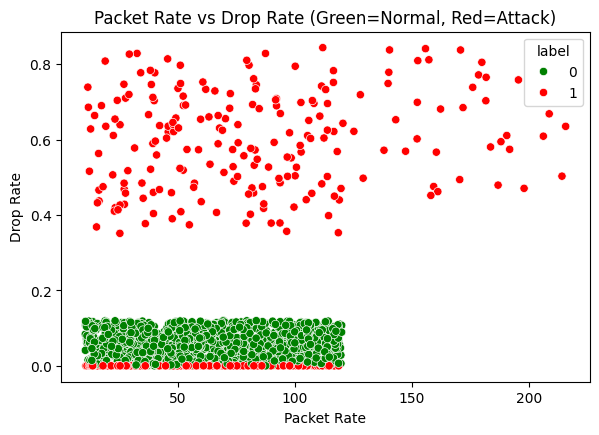

In [15]:
plt.figure(figsize=(15, 10))

# 1. Attack Visualization
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='packet_rate', y='drop_rate', hue='label', palette=['green', 'red'])
plt.title('Packet Rate vs Drop Rate (Green=Normal, Red=Attack)')
plt.xlabel('Packet Rate')
plt.ylabel('Drop Rate')

Text(0.5, 1.0, 'Energy Level Distribution')

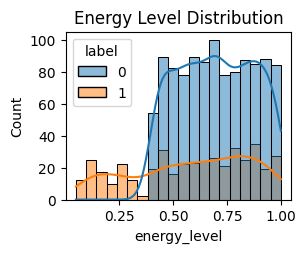

In [16]:
# 2. Energy Level Distribution
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='energy_level', hue='label', bins=20, kde=True)
plt.title('Energy Level Distribution')

Text(50.722222222222214, 0.5, 'True')

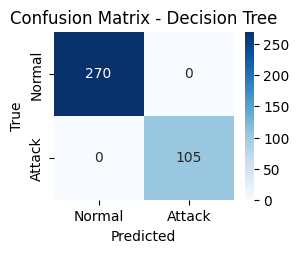

In [17]:
# 3. Confusion Matrix (Decision Tree)
plt.subplot(2, 2, 3)
y_pred_dt = models['DecisionTree'].predict(X_test)
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('True')

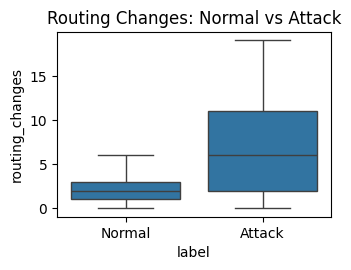


🎉 All sections completed successfully!
You can now save the best model using: joblib.dump(models['DecisionTree'], 'lids_model.pkl')


In [18]:
# 4. Routing Changes
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='label', y='routing_changes')
plt.title('Routing Changes: Normal vs Attack')
plt.xticks([0, 1], ['Normal', 'Attack'])

plt.tight_layout()
plt.show()

print("\n🎉 All sections completed successfully!")
print("You can now save the best model using: joblib.dump(models['DecisionTree'], 'lids_model.pkl')")

# ===============================
# 9. Save Best Model & Scaler
# ===============================

In [19]:
# ===================== SAVE THE BEST MODEL =====================
import joblib
import os

# Create models folder if not exists
os.makedirs('models', exist_ok=True)

# Save Decision Tree as the best lightweight model
best_model = models['DecisionTree']
joblib.dump(best_model, 'models/lids_decision_tree.pkl')

# Also save the scaler (very important!)
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Best Model (Decision Tree) and Scaler saved successfully in 'models/' folder!")
print("Files created:")
print("   - models/lids_decision_tree.pkl")
print("   - models/scaler.pkl")

✅ Best Model (Decision Tree) and Scaler saved successfully in 'models/' folder!
Files created:
   - models/lids_decision_tree.pkl
   - models/scaler.pkl
